Load the `ISLR2` and `tidyverse` packages.

In [10]:
library('tidyverse')
library('ISLR2')
library('tidymodels')



── Attaching packages ────────────────────────────────────── tidymodels 1.1.0 ──

✔ broom        1.0.12     ✔ rsample      1.3.2 
✔ dials        1.4.3      ✔ tune         1.1.1 
✔ infer        1.1.0      ✔ workflows    1.3.0 
✔ modeldata    1.5.1      ✔ workflowsets 1.0.1 
✔ parsnip      1.5.0      ✔ yardstick    1.4.0 
✔ recipes      1.3.2      

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filter()   masks stats::filter()
✖ recipes::fixed()  masks stringr::fixed()
✖ dplyr::lag()      masks stats::lag()
✖ yardstick::spec() masks readr::spec()
✖ recipes::step()   masks stats::step()
• Use suppressPackageStartupMessages() to eliminate package startup messages



`glimpse` the `Auto` dataset (this comes from the `ISLR2` package).

In [3]:
Auto |> glimpse()


Rows: 392
Columns: 9
$ mpg          <dbl> 18, 15, 18, 16, 17, 15, 14, 14, 14, 15, 15, 14, 15, 14, 2…
$ cylinders    <int> 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 4, 6, 6, 6, 4, …
$ displacement <dbl> 307, 350, 318, 304, 302, 429, 454, 440, 455, 390, 383, 34…
$ horsepower   <int> 130, 165, 150, 150, 140, 198, 220, 215, 225, 190, 170, 16…
$ weight       <int> 3504, 3693, 3436, 3433, 3449, 4341, 4354, 4312, 4425, 385…
$ acceleration <dbl> 12.0, 11.5, 11.0, 12.0, 10.5, 10.0, 9.0, 8.5, 10.0, 8.5, …
$ year         <int> 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 7…
$ origin       <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 3, …
$ name         <fct> chevrolet chevelle malibu, buick skylark 320, plymouth sa…


Plot `mpg`  as a function of `displacement`.

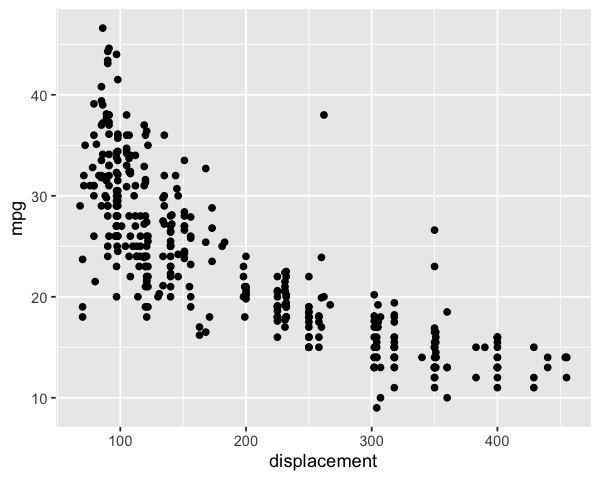

In [8]:
options(repr.plot.height = 4, repr.plot.width = 5)

ggplot(Auto, aes(x = displacement, y = mpg)) +
    geom_point()



❓Does the relationship of `mpg` to `displacement` look linear?

No, the, relationship between mpg and displacement does not appear linear. While there does appear to be a relationship where the mpg decreases as displacement increases, the relationship appears to have a plot resembling exponential decay, which would have more a curved fit.



Model `mpg` as a function of `displacement` and `cylinders`. 

- Transform the `displacement` variable using a `spline` or `polynomial` transform. (Hint: use `step_ns` or `step_poly`).
- Combine `step_mutate(cyl_cat = factor(cylinders))` followed by `step_dummy(cyl_cat)` and `step_rm(cylinders)` to convert `cylinders` to categorical data for the model.

Assuming you name your fitted model `mod_fit` the code below can be used to visualize your model:

```r
predict(mod_fit, rec |> juice()) |>
    bind_cols(Auto) |>
ggplot(aes(x = displacement, y = mpg)) +
    geom_point(size = 1, alpha = 0.35) +
    geom_line(aes(y = .pred, color = factor(cylinders)), linewidth = 1)
```

**Create and visualize your model below...**

In [79]:
#Spline model
rec = recipe(mpg ~ ., data = Auto) |>
    step_ns(displacement, deg_free = 3) |>
    step_mutate(cyl_cat = factor(cylinders)) |>
    step_dummy(cyl_cat) |>
    step_rm(cylinders) |>
    prep()

mod = linear_reg() |> set_engine('lm')

#Untrained recipe
rec_untrained <- recipe(mpg ~ ., data = Auto)

wf = workflow() |>
    add_recipe(rec_untrained) |>
    add_model(mod)

wf_fit = fit(wf, data = Auto)

In [80]:
Auto_with_pred = augment(wf_fit, new_data = Auto)
Auto_with_pred |> head()

Warning message in predict.lm(object = object$fit, newdata = new_data, type = "response", :
“prediction from a rank-deficient fit may be misleading”


.pred,.resid,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
<dbl>,<dbl>,<dbl>,<int>,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<fct>
16.19087,1.809128e+00,18,8,307,130,3504,12.0,70,1,chevrolet chevelle malibu
15.00000,-2.842171e-14,15,8,350,165,3693,11.5,70,1,buick skylark 320
18.00000,8.526513e-14,18,8,318,150,3436,11.0,70,1,plymouth satellite
16.00000,3.907985e-14,16,8,304,150,3433,12.0,70,1,amc rebel sst
17.00000,5.329071e-14,17,8,302,140,3449,10.5,70,1,ford torino
13.07022,1.929777e+00,15,8,429,198,4341,10.0,70,1,ford galaxie 500


In [84]:
mod_fit= mod |> fit(mpg ~ ., data = rec |> juice())

Warning message in predict.lm(object = object$fit, newdata = new_data, type = "response", :
“prediction from a rank-deficient fit may be misleading”


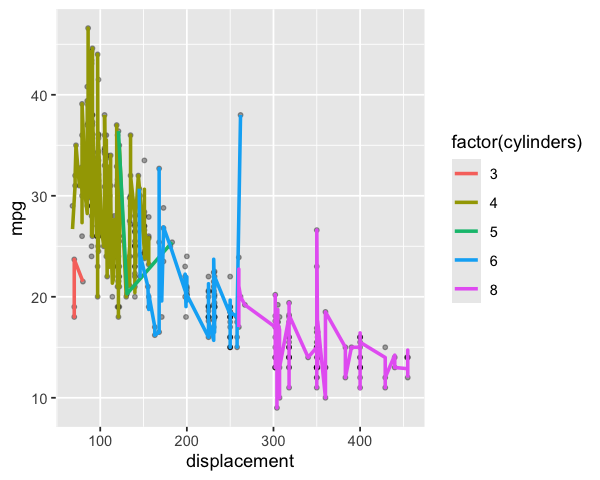

In [85]:
#Spline Plot
predict(mod_fit, rec |> juice()) |>
    bind_cols(Auto) |>
ggplot(aes(x = displacement, y = mpg)) +
    geom_point(size = 1, alpha = 0.35) +
    geom_line(aes(y = .pred, color = factor(cylinders)), linewidth = 1)

Warning message in geom_line(aes(x = displacement, xend = displacement, y = .pred, :
“Ignoring unknown aesthetics: xend and yend”


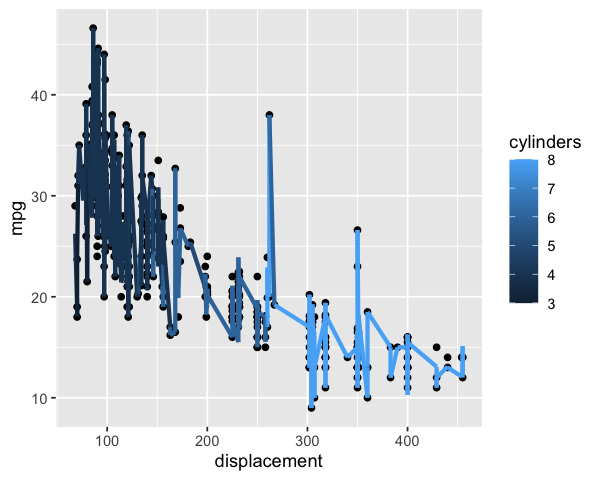

In [95]:
#Spline plot
ggplot(Auto_with_pred) +
    geom_point(aes(x = displacement, y = mpg)) +
    geom_line(aes(x = displacement, y = .pred, color = cylinders), linewidth = 1.2) +
    geom_line(aes(x = displacement, xend = displacement, y = .pred, yend = mpg, color = cylinders), alpha = 0.25)

Conclusion: A polynomial fit may have been more suitable versus a spline fit. Two versions of the plot were made, one with the workflow and augment() function included and one with the fitted model. 